TITANIC SURVIVAL PREDICTION 

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Dataset

In [2]:
data = pd.read_csv("Titanic-Dataset (1).csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check Dataset Information

In [3]:
print("\nDataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin       

Data Cleaning

In [4]:
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data.drop('Cabin', axis=1, inplace=True)

Convert Categorical Data

In [5]:
label_encoder = LabelEncoder()

data['Sex'] = label_encoder.fit_transform(data['Sex'])

data['Embarked'] = label_encoder.fit_transform(data['Embarked'])

Select Features and Target

In [6]:
X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

y = data['Survived']

Split Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Make Predictions

In [9]:
y_pred = model.predict(X_test)

Check Accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:")
print(accuracy)


Model Accuracy:
0.8100558659217877


Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[90 15]
 [19 55]]


Plot Confusion Matrix

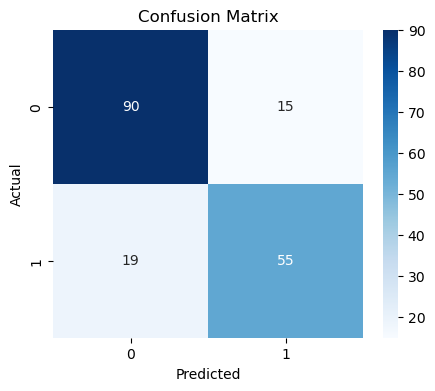

In [12]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [13]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Sample Prediction

In [14]:
sample_data = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1],      # Male = 1, Female = 0
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [2]
})

prediction = model.predict(sample_data)

print("\nSample Prediction")

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")


Sample Prediction
Passenger Did Not Survive
